# CloudShield — EDA & Data Audit

**Project:** Network Traffic Threat Detection & QoS Degradation Forecasting  
**Dataset:** UNSW-NB15  
**Review 1 — Sections A & B**

## 1. Problem Statement

Build three ML tracks on network flow data:
1. **Regression** — predict packet loss (`sloss`) as a QoS degradation proxy
2. **Classification** — identify attack type (`attack_cat`, 10 classes)
3. **Clustering** — discover workload profiles without labels

This notebook covers EDA and preprocessing for Review 1.

In [2]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.plotting import set_style, save
from src.preprocessing import get_dataset, load_raw

set_style()
pd.set_option('display.max_columns', 50)
print('Imports OK')

Imports OK


## 2. Dataset Audit (A1)

Load raw data and report shape, dtypes, missing values, duplicates, and target distribution.

In [3]:
# Load raw data
df = load_raw()
print(f'Shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Shape: (257673, 45)

First 5 rows:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,0,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,0,600000000.0,0.0,0,0,0.006,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,0,0,0.010,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0


In [4]:
# Data types
print('Data types:')
df.dtypes.value_counts()

Data types:


int64      30
float64    11
object      4
Name: count, dtype: int64

In [5]:
# Missing values
missing = df.isnull().sum()
print(f'Total missing values: {missing.sum()}')
print(f'\nColumns with missing values:')
print(missing[missing > 0] if missing.sum() > 0 else 'None')

Total missing values: 0

Columns with missing values:
None


In [6]:
# Duplicates
n_dup = df.duplicated().sum()
print(f'Exact duplicates: {n_dup} ({n_dup/len(df)*100:.1f}%)')
print(f'Rows after dedup: {len(df) - n_dup}')

Exact duplicates: 0 (0.0%)
Rows after dedup: 257673


In [7]:
# Target distribution - attack_cat
print('Attack category distribution:')
df['attack_cat'].value_counts()

Attack category distribution:


attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64

In [8]:
# Target distribution - label (binary)
print('Label distribution (0=Normal, 1=Attack):')
df['label'].value_counts()

Label distribution (0=Normal, 1=Attack):


label
1    164673
0     93000
Name: count, dtype: int64

In [9]:
# Regression target - sloss
print('Regression target (sloss) statistics:')
df['sloss'].describe()

Regression target (sloss) statistics:


count    257673.000000
mean          4.889317
std          65.574953
min           0.000000
25%           0.000000
50%           0.000000
75%           3.000000
max        5319.000000
Name: sloss, dtype: float64

In [10]:
# Categorical feature levels
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns and their levels:')
for col in cat_cols:
    print(f'  {col}: {df[col].nunique()} levels')

Categorical columns and their levels:
  proto: 133 levels
  service: 13 levels
  state: 11 levels
  attack_cat: 10 levels


### Audit Observations

- **257,673 rows × 45 columns** — combined from both partition files
- **No missing values** — the curated partition files are clean
- **36.8% duplicates** — must be removed before splitting to avoid test contamination
- **10 attack classes** — highly imbalanced (Normal 93k vs Worms 174)
- **`sloss` is right-skewed** — most flows lose 0 packets, long tail to 5,319
- **`proto` has 133 levels** — needs rare-level folding before one-hot encoding

## 3. Distribution Plots (A2)

Histograms for all numeric features.

Numeric features: 39
Saved: 01_feature_distributions.png


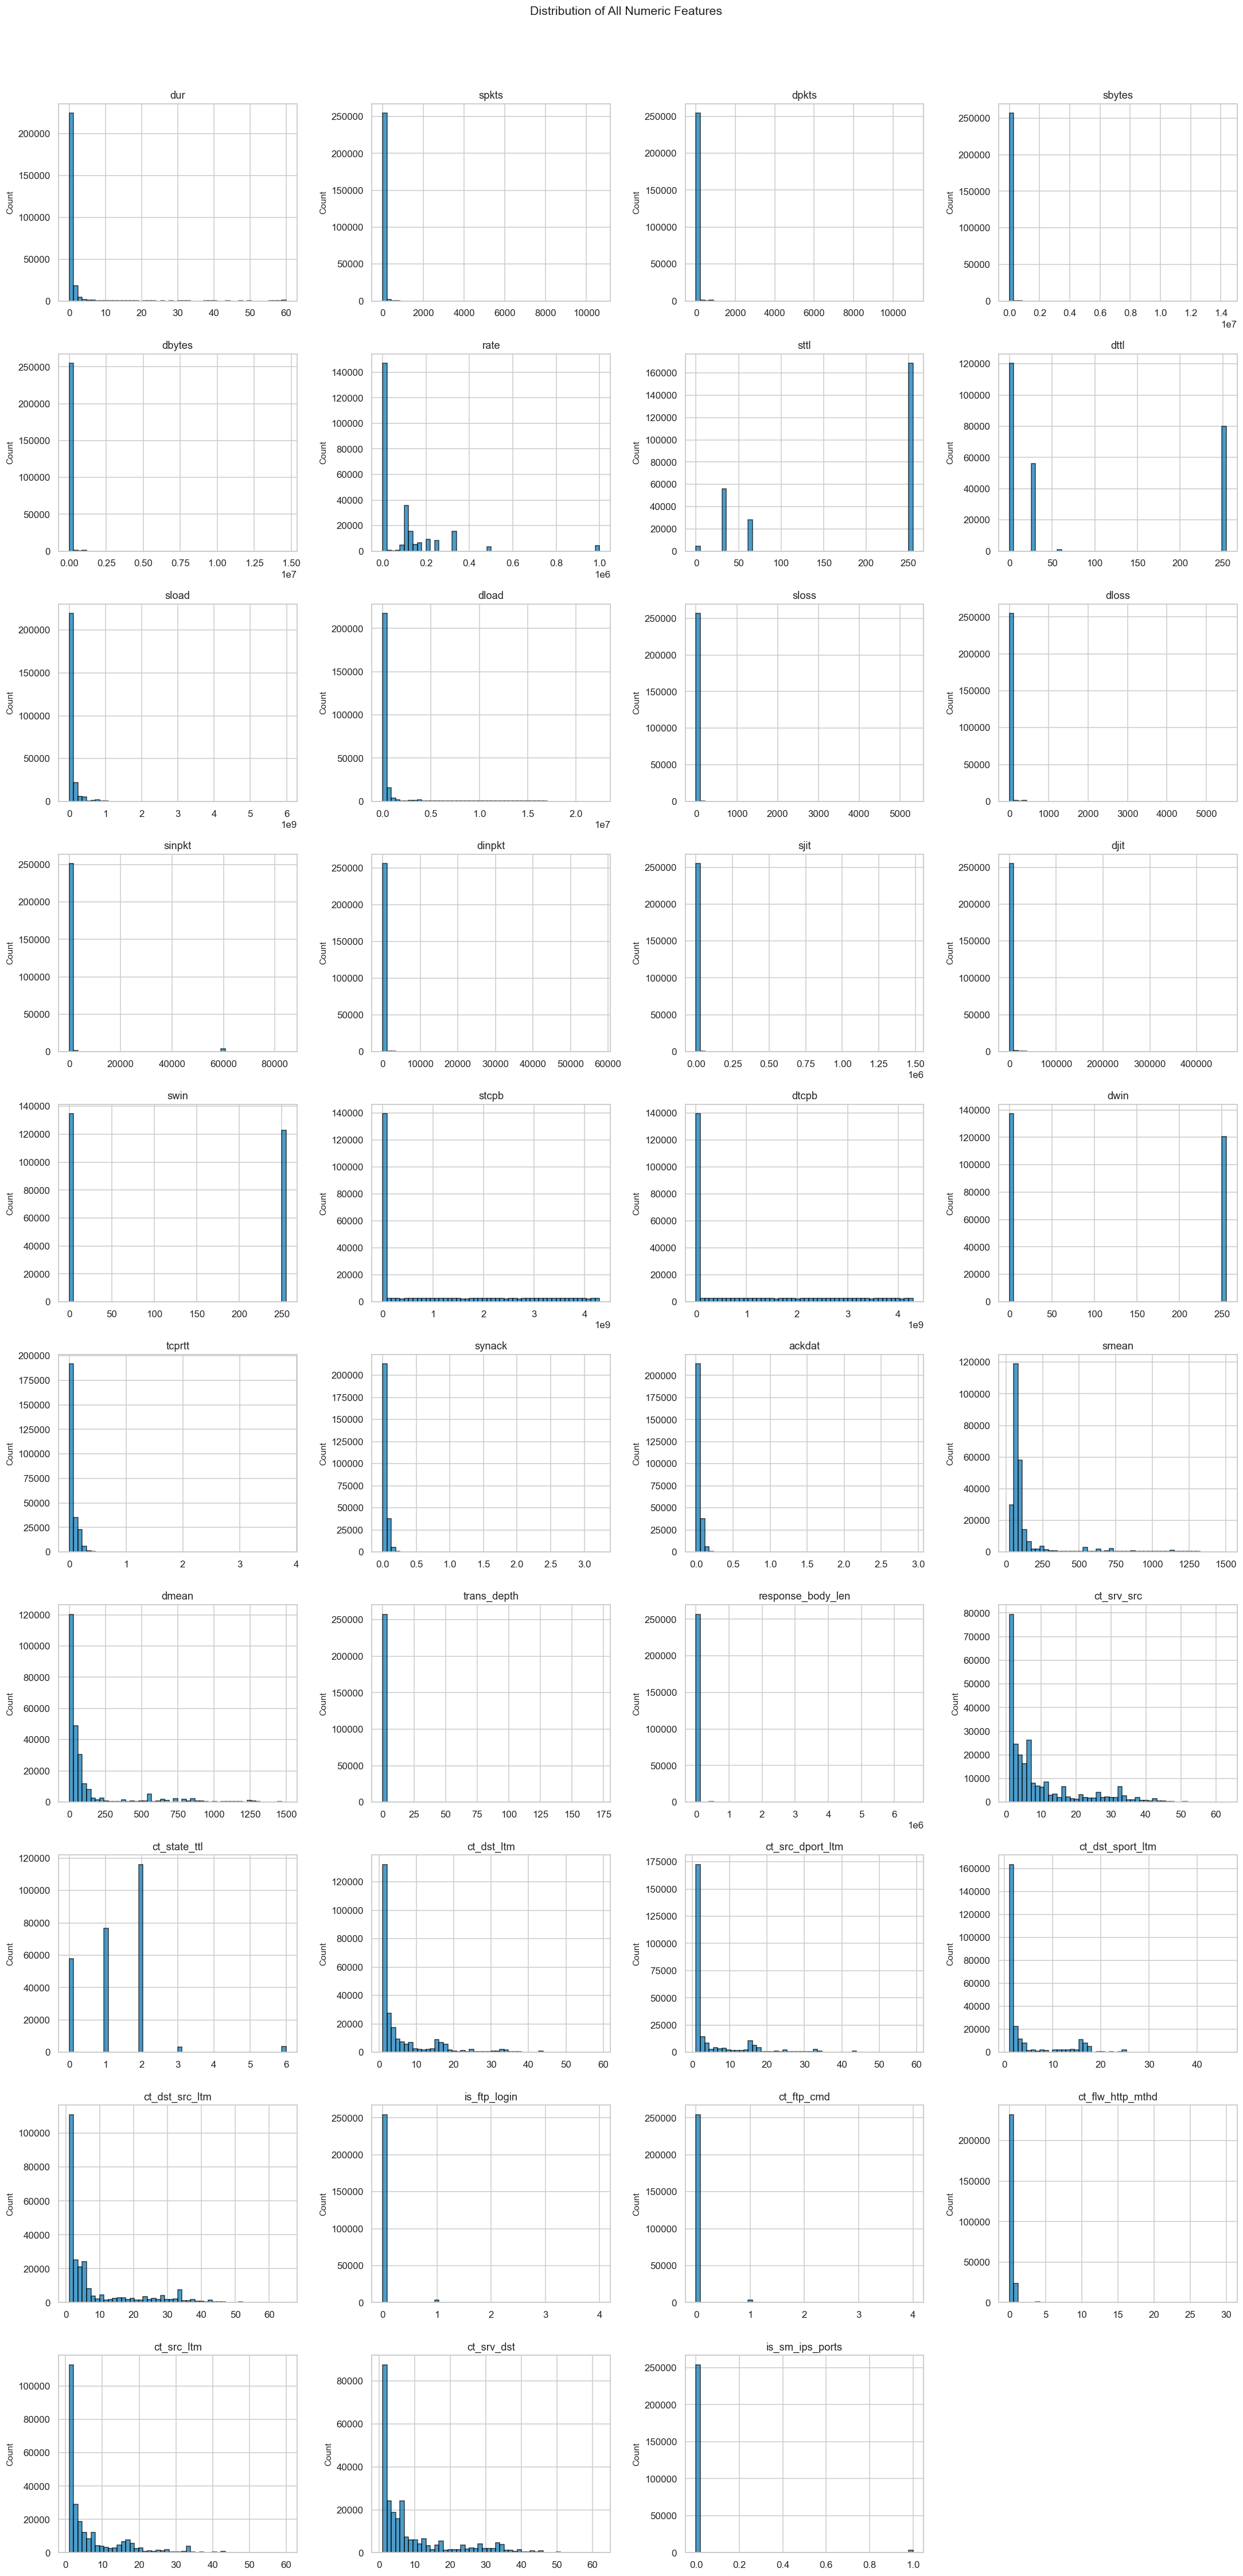

In [11]:
# Get numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['id', 'label']]  # drop id and label
print(f'Numeric features: {len(num_cols)}')

# Histogram grid
n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Numeric Features', fontsize=14, y=1.02)
save(fig, '01_feature_distributions')

**Observation:** Most features are heavily right-skewed. Flow volume features (`sbytes`, `dbytes`, `spkts`, `dpkts`) span several orders of magnitude. This confirms the need for scaling and suggests tree-based models may outperform linear ones.

Saved: 02_log_loss_distributions.png


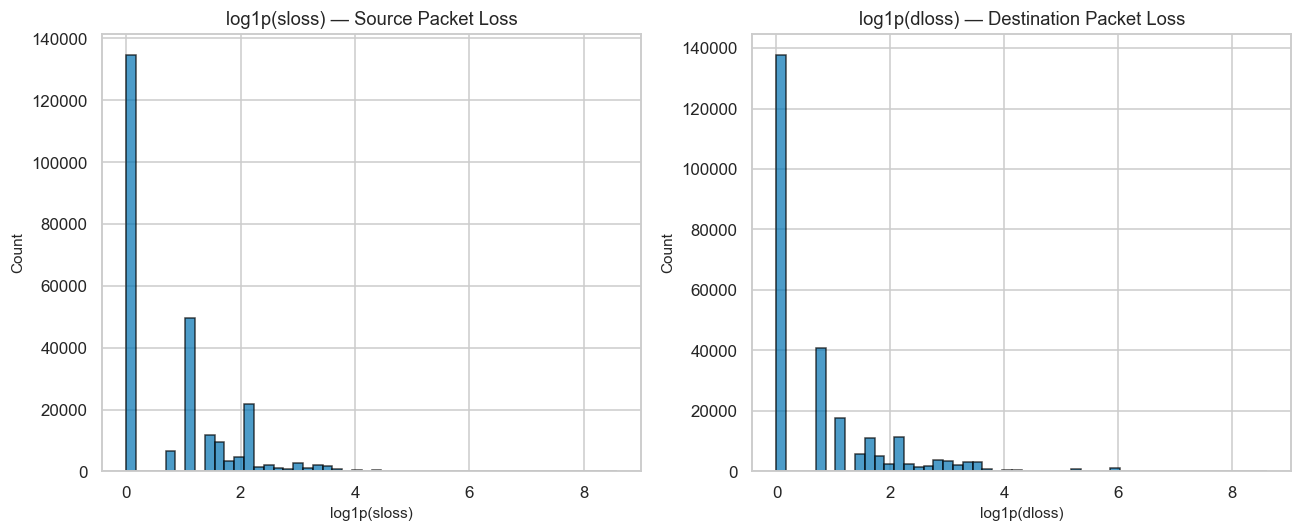

In [12]:
# Log-scale histogram of regression targets
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(np.log1p(df['sloss']), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('log1p(sloss) — Source Packet Loss')
axes[0].set_xlabel('log1p(sloss)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['dloss']), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('log1p(dloss) — Destination Packet Loss')
axes[1].set_xlabel('log1p(dloss)')
axes[1].set_ylabel('Count')

save(fig, '02_log_loss_distributions')

**Observation:** Even after log transform, both targets show bimodal distributions — a large spike at zero (no loss) and a spread of non-zero values. This suggests a zero-inflated pattern that regression models must handle.

Saved: 03_categorical_distributions.png


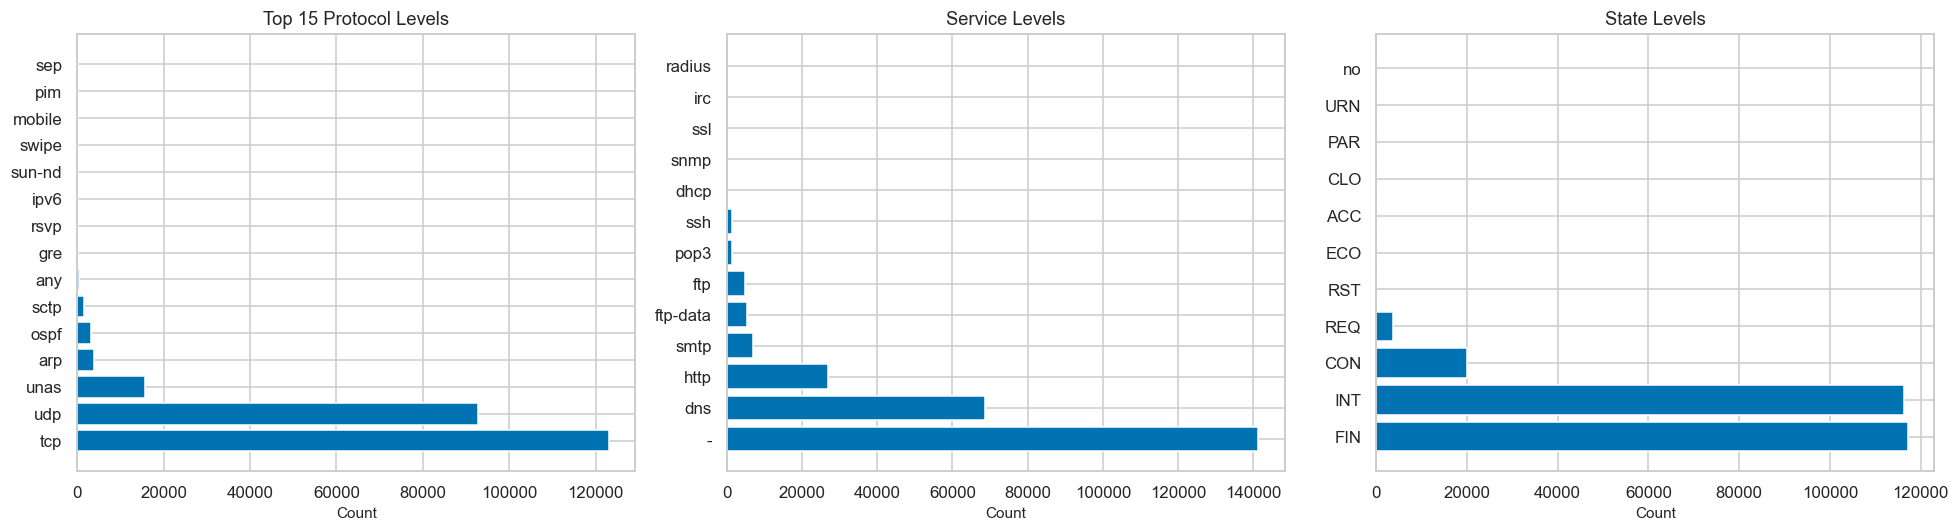

In [13]:
# Categorical feature count plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Proto (top 15)
top_proto = df['proto'].value_counts().head(15)
axes[0].barh(top_proto.index, top_proto.values)
axes[0].set_title('Top 15 Protocol Levels')
axes[0].set_xlabel('Count')

# Service
svc_counts = df['service'].value_counts()
axes[1].barh(svc_counts.index, svc_counts.values)
axes[1].set_title('Service Levels')
axes[1].set_xlabel('Count')

# State
state_counts = df['state'].value_counts()
axes[2].barh(state_counts.index, state_counts.values)
axes[2].set_title('State Levels')
axes[2].set_xlabel('Count')

save(fig, '03_categorical_distributions')

**Observation:** `proto` is dominated by a few protocols (tcp, udp, unas). `service` has '-' as the majority category (62%), indicating 'not much used service'. `state` is dominated by FIN and INT. Rare levels will be folded into 'other' during preprocessing.

## 4. Target Distribution (A2)

Saved: 04_attack_category_distribution.png


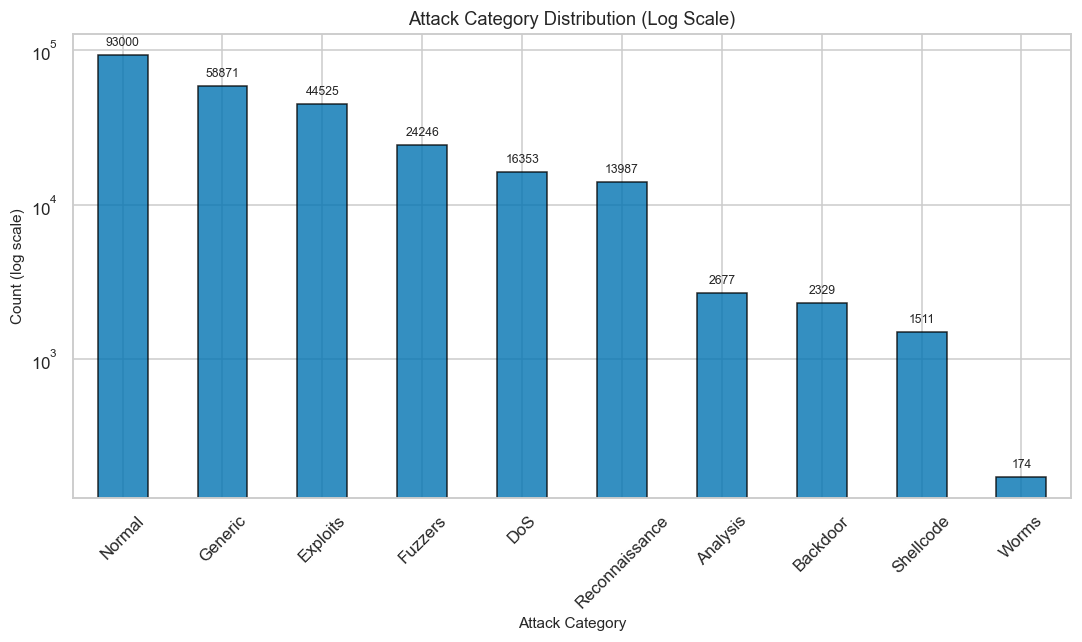

In [14]:
# Attack category distribution (log scale)
fig, ax = plt.subplots(figsize=(10, 6))
attack_counts = df['attack_cat'].value_counts()
attack_counts.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.8)
ax.set_yscale('log')
ax.set_title('Attack Category Distribution (Log Scale)')
ax.set_xlabel('Attack Category')
ax.set_ylabel('Count (log scale)')
ax.tick_params(axis='x', rotation=45)

# Annotate counts
for i, (cat, count) in enumerate(attack_counts.items()):
    ax.text(i, count*1.1, str(count), ha='center', va='bottom', fontsize=8)

save(fig, '04_attack_category_distribution')

**Observation:** Extreme class imbalance — Normal (93k) vs Worms (174) is a 500:1 ratio. `Generic` is the 2nd largest class (58k) but will drop significantly after deduplication. This imbalance motivates `class_weight='balanced'` and SMOTE for classification.

Saved: 05_sloss_distribution.png


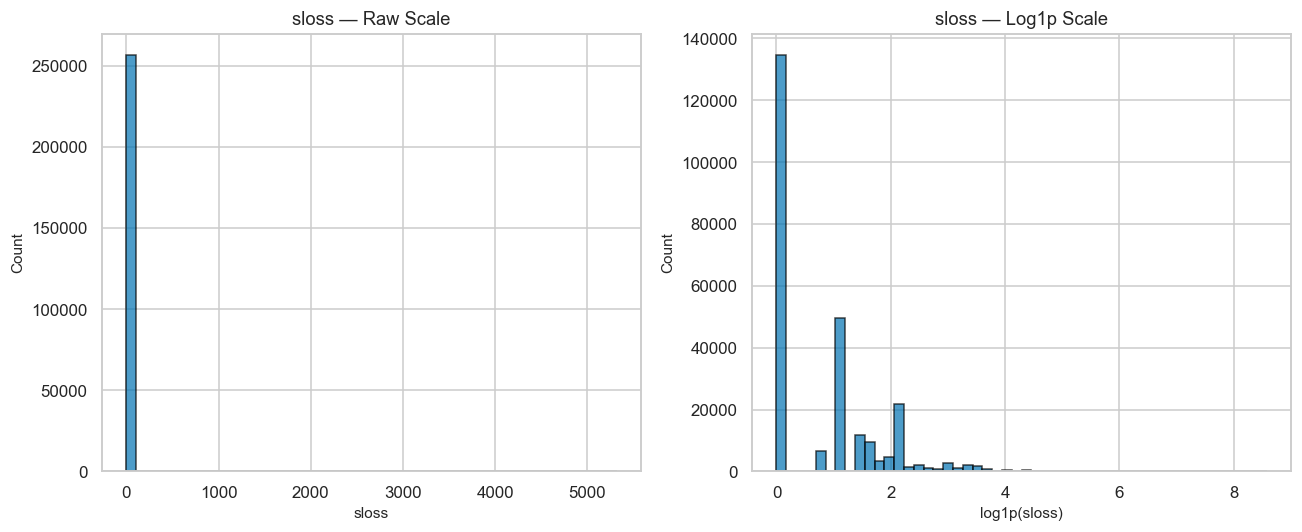

In [15]:
# Regression target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['sloss'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('sloss — Raw Scale')
axes[0].set_xlabel('sloss')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['sloss']), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('sloss — Log1p Scale')
axes[1].set_xlabel('log1p(sloss)')
axes[1].set_ylabel('Count')

save(fig, '05_sloss_distribution')

**Observation:** `sloss` has 28.3% zeros and a heavy right tail (max 5,319). The log transform compresses the tail and makes the distribution more suitable for regression. The heavy tail means raw-scale R2 will be dominated by a few extreme values.

## 5. Correlation Heatmap (A2)

Full correlation matrix and focused view on sloss correlations.

Saved: 06_correlation_heatmap_full.png


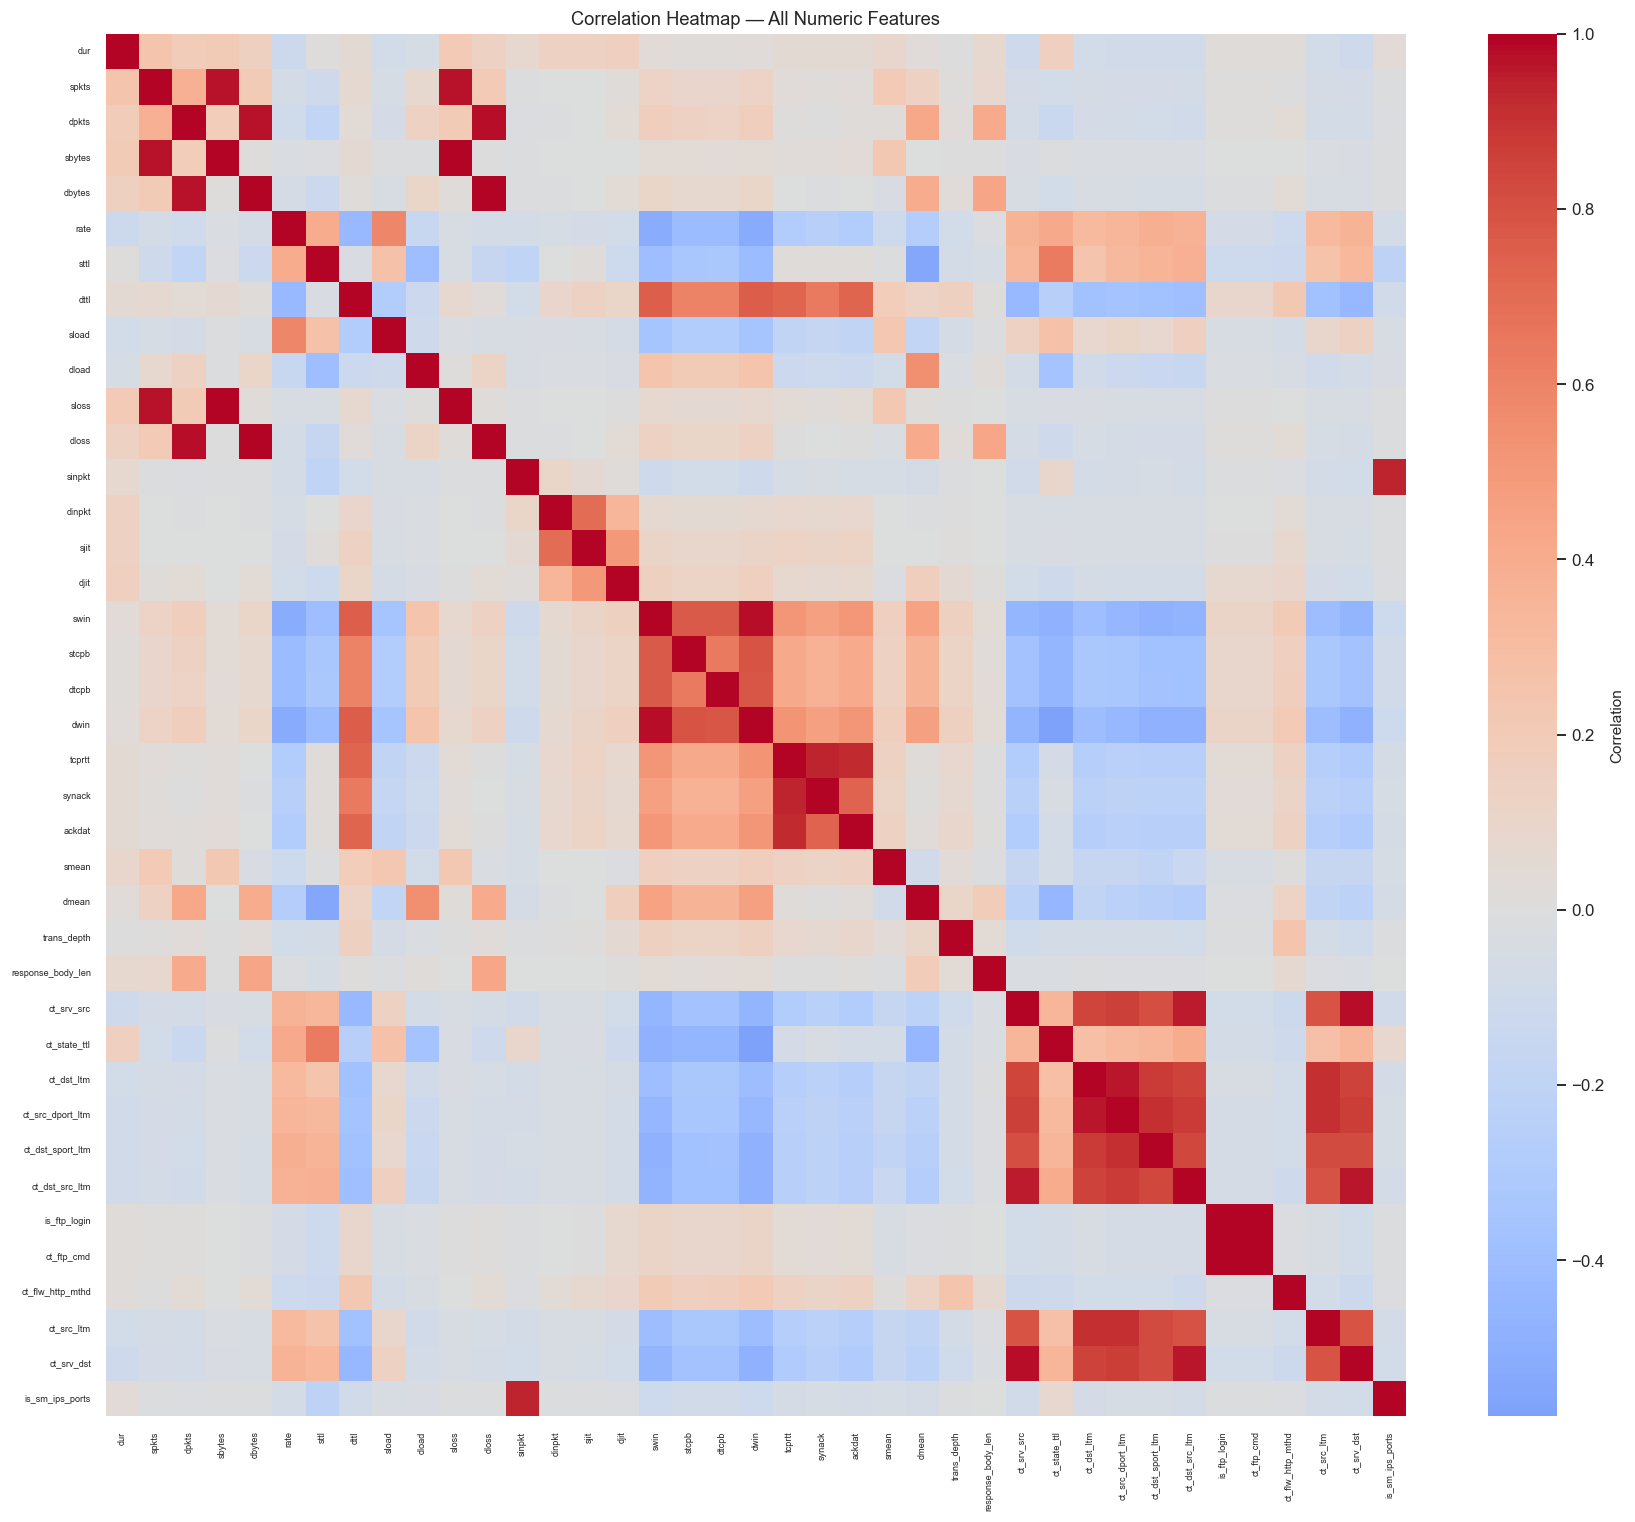

In [16]:
# Full correlation heatmap
num_df = df.select_dtypes(include=[np.number]).drop(columns=['id', 'label'], errors='ignore')
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            xticklabels=True, yticklabels=True,
            cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Heatmap — All Numeric Features')
ax.tick_params(axis='x', rotation=90, labelsize=6)
ax.tick_params(axis='y', rotation=0, labelsize=6)

save(fig, '06_correlation_heatmap_full')

**Observation:** Several feature groups are highly correlated (e.g., `spkts`/`sbytes`/`sload`, `dpkts`/`dbytes`/`dload`). This multicollinearity affects linear models but not tree-based models. The leakage trap is visible — `sloss` correlates ~0.99 with `sbytes` and `spkts`.

Saved: 07_sloss_correlations.png


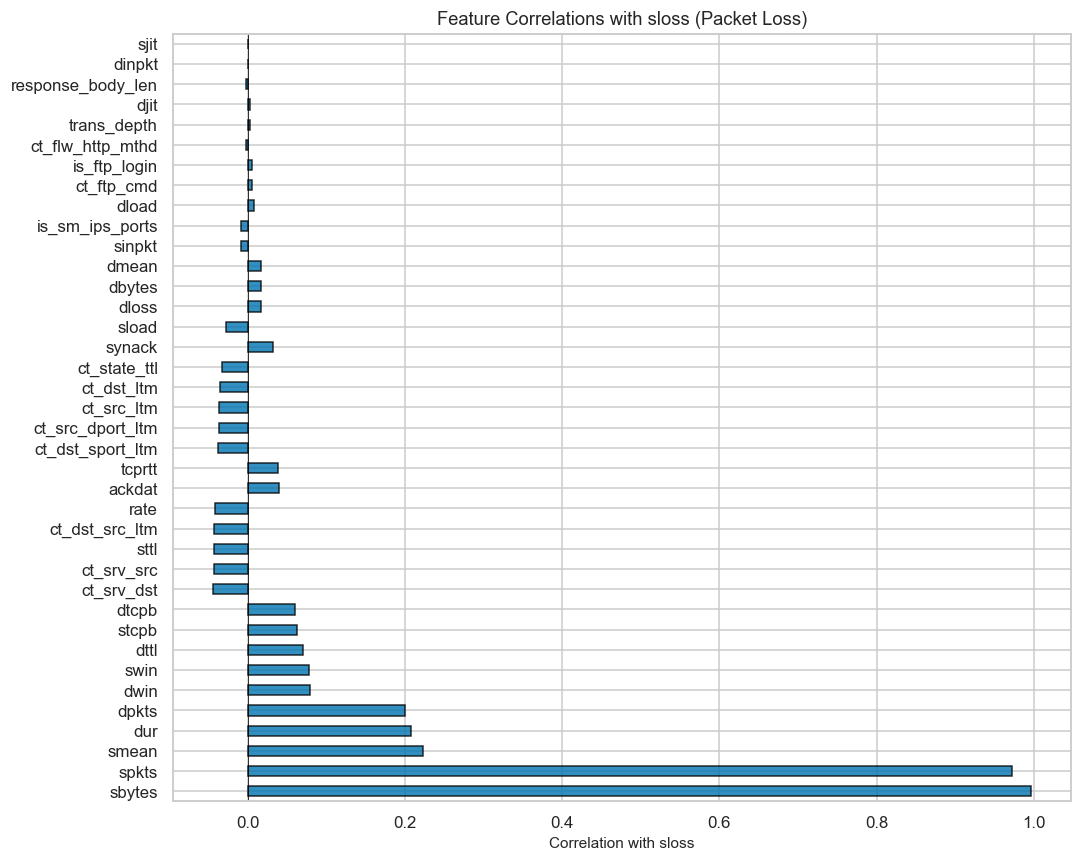

In [17]:
# Focused correlation with sloss
sloss_corr = corr['sloss'].drop('sloss').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sloss_corr.plot(kind='barh', ax=ax, edgecolor='black', alpha=0.8)
ax.set_title('Feature Correlations with sloss (Packet Loss)')
ax.set_xlabel('Correlation with sloss')
ax.axvline(x=0, color='black', linewidth=0.5)

save(fig, '07_sloss_correlations')

**Observation — THE LEAKAGE TRAP:** `sbytes` (r=0.997), `spkts` (r=0.974), `smean`, `sload`, and `rate` are algebraically tied to `sloss`. These are not predictive features — they are deterministic functions of the same packet stream. Including them gives R2 ≈ 0.998 for every tree model, making the ranking table meaningless. The honest framing drops these columns.

## 6. Feature-Target Scatter Plots (A2)

At least two scatter plots showing feature-target relationships.

Saved: 08_scatter_spkts_vs_sloss.png


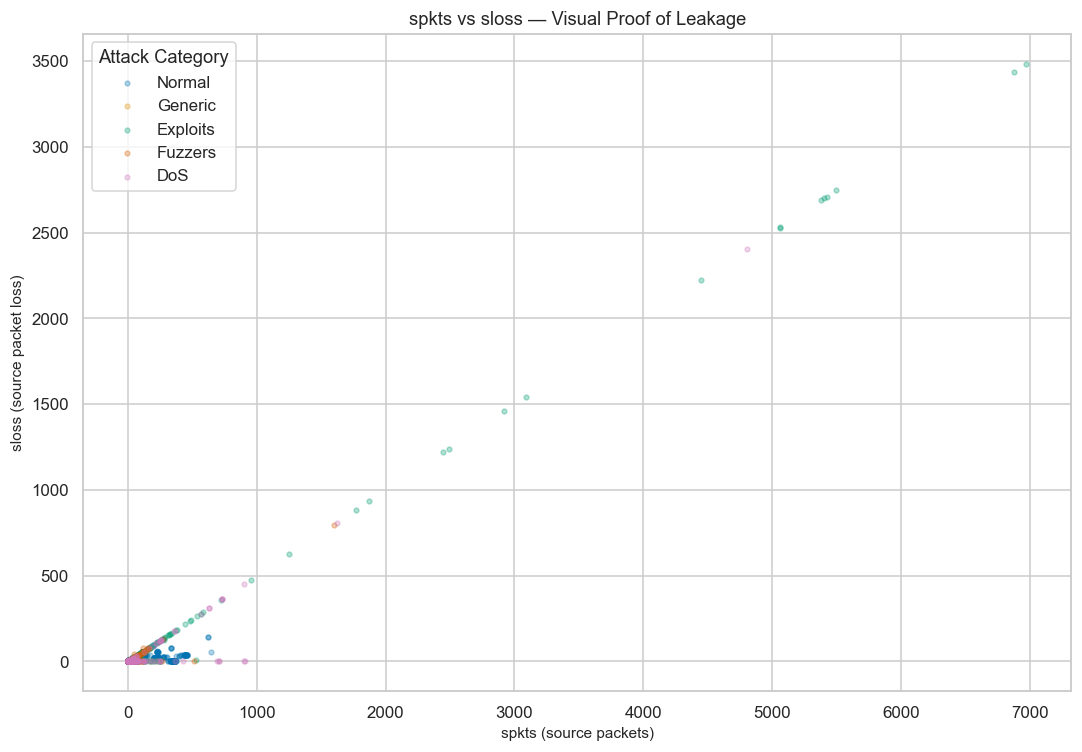

In [18]:
# Subsample for scatter plots (avoid overplotting)
sample = df.sample(n=min(20000, len(df)), random_state=42)

# spkts vs sloss (colored by attack_cat)
fig, ax = plt.subplots(figsize=(10, 7))
top_cats = df['attack_cat'].value_counts().head(5).index
for cat in top_cats:
    mask = sample['attack_cat'] == cat
    ax.scatter(sample.loc[mask, 'spkts'], sample.loc[mask, 'sloss'], 
              alpha=0.3, label=cat, s=10)
ax.set_xlabel('spkts (source packets)')
ax.set_ylabel('sloss (source packet loss)')
ax.set_title('spkts vs sloss — Visual Proof of Leakage')
ax.legend(title='Attack Category')

save(fig, '08_scatter_spkts_vs_sloss')

**Observation:** The near-linear ceiling visually proves the leakage — `sloss` cannot exceed `spkts` by definition. Any model using `spkts` is essentially predicting a variable from itself. This is why the honest regression framing drops these columns.

Saved: 09_scatter_dur_vs_sloss.png


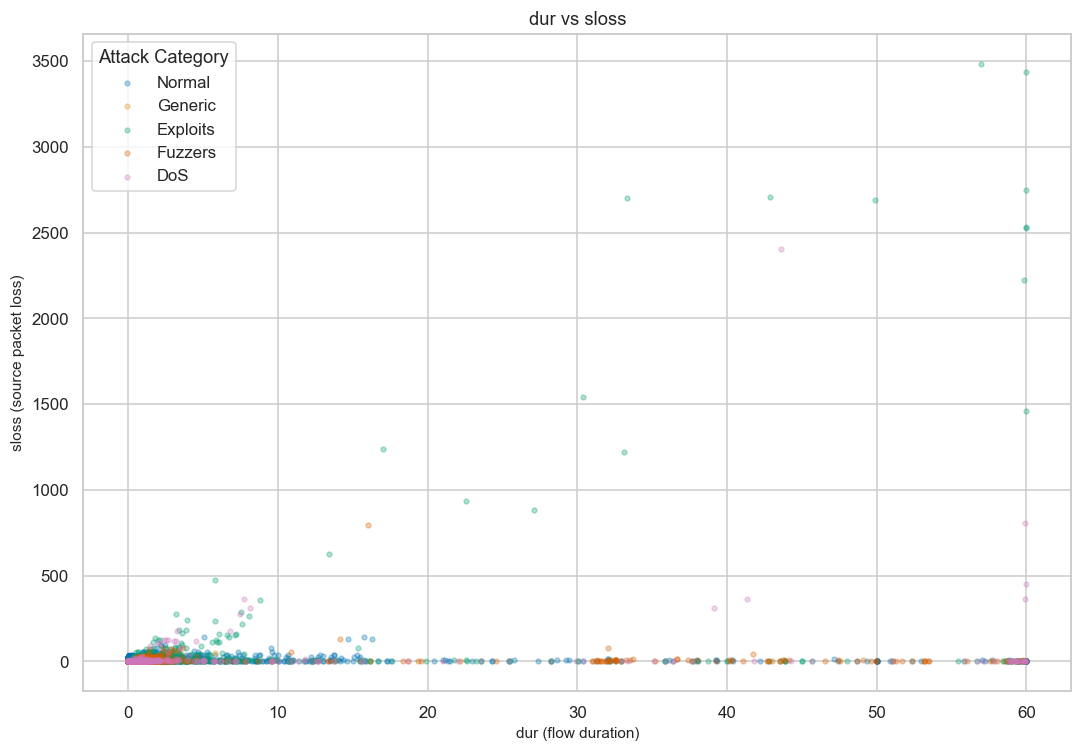

In [19]:
# dur vs sloss
fig, ax = plt.subplots(figsize=(10, 7))
for cat in top_cats:
    mask = sample['attack_cat'] == cat
    ax.scatter(sample.loc[mask, 'dur'], sample.loc[mask, 'sloss'], 
              alpha=0.3, label=cat, s=10)
ax.set_xlabel('dur (flow duration)')
ax.set_ylabel('sloss (source packet loss)')
ax.set_title('dur vs sloss')
ax.legend(title='Attack Category')

save(fig, '09_scatter_dur_vs_sloss')

**Observation:** Flow duration shows a weaker, more diffuse relationship with packet loss. This is a genuine predictive signal rather than a tautology. Longer flows tend to have higher absolute loss, but the relationship is noisy.

Saved: 10_scatter_sttl_vs_sloss.png


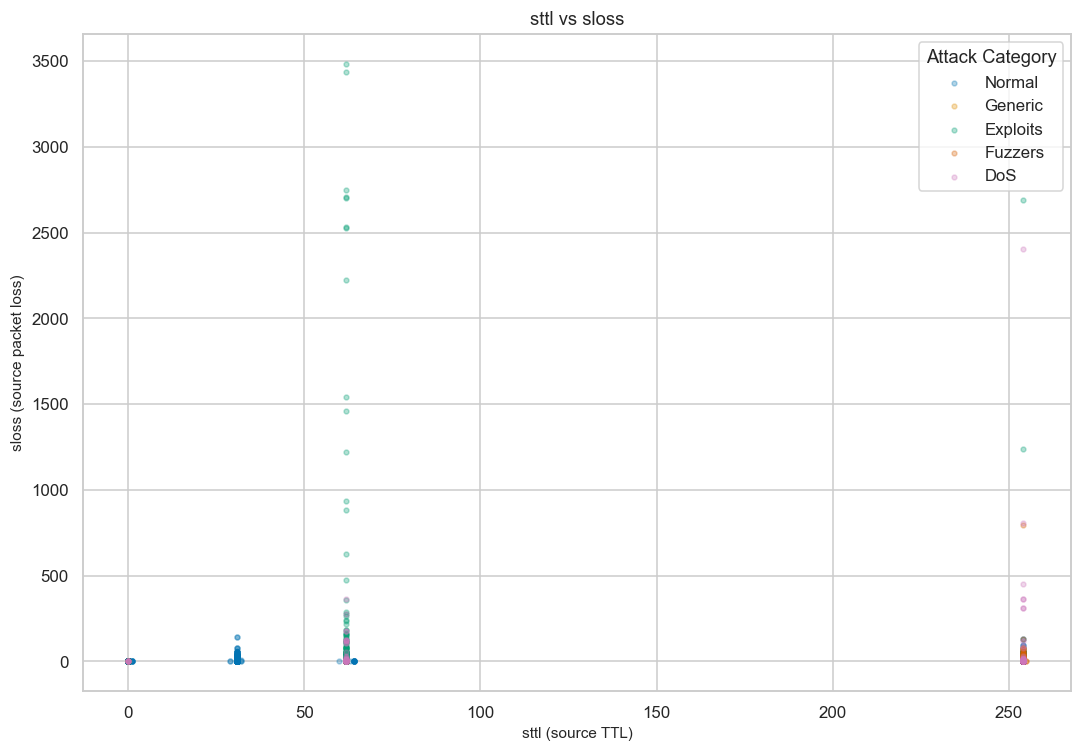

In [20]:
# sttl vs sloss
fig, ax = plt.subplots(figsize=(10, 7))
for cat in top_cats:
    mask = sample['attack_cat'] == cat
    ax.scatter(sample.loc[mask, 'sttl'], sample.loc[mask, 'sloss'], 
              alpha=0.3, label=cat, s=10)
ax.set_xlabel('sttl (source TTL)')
ax.set_ylabel('sloss (source packet loss)')
ax.set_title('sttl vs sloss')
ax.legend(title='Attack Category')

save(fig, '10_scatter_sttl_vs_sloss')

**Observation:** `sttl` (source TTL) shows a striking pattern — different attack categories cluster at specific TTL values. This is a famously sharp separator in UNSW-NB15 (partly an artifact of the IXIA testbed generator). It is a strong but potentially overfit-prone feature.

## 7. Class-Conditional Views (A2)

Box plots showing feature distributions per attack category.

C:\Users\chand\AppData\Local\Temp\ipykernel_121472\4006226303.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='attack_cat', y='sloss', order=order, ax=ax,


Saved: 11_boxplot_sloss_per_attack.png


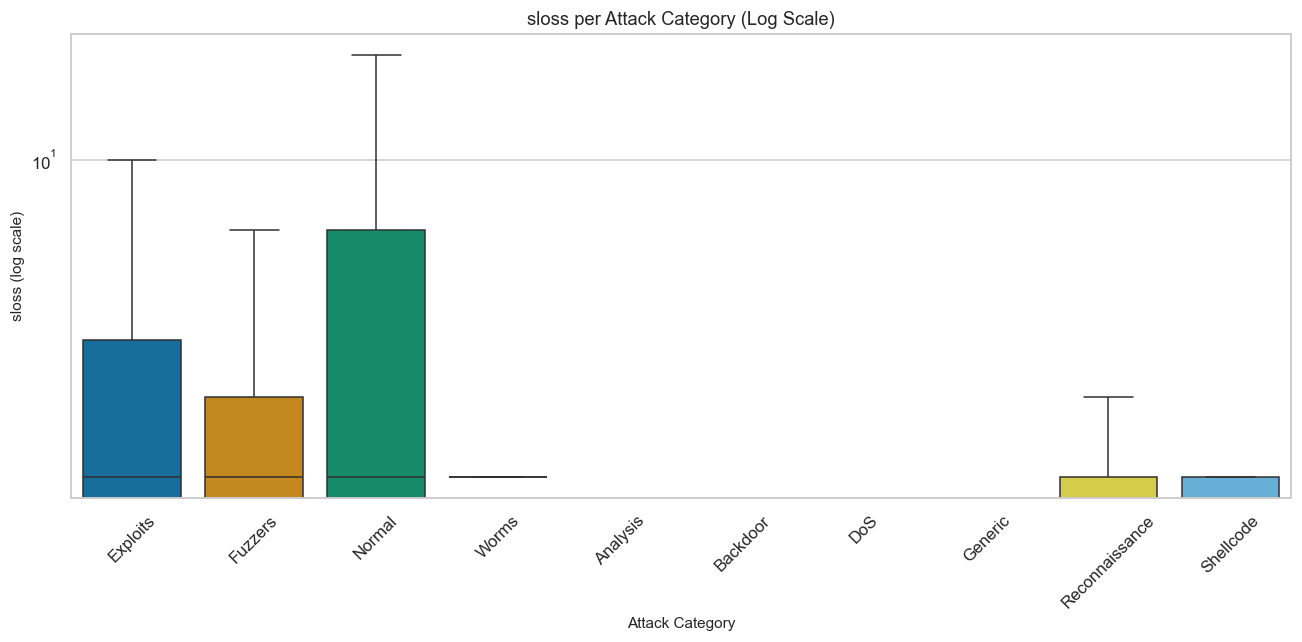

In [21]:
# Box plot: sloss per attack_cat
fig, ax = plt.subplots(figsize=(12, 6))
order = df.groupby('attack_cat')['sloss'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='attack_cat', y='sloss', order=order, ax=ax, 
            showfliers=False, palette='colorblind')
ax.set_yscale('log')
ax.set_title('sloss per Attack Category (Log Scale)')
ax.set_xlabel('Attack Category')
ax.set_ylabel('sloss (log scale)')
ax.tick_params(axis='x', rotation=45)

save(fig, '11_boxplot_sloss_per_attack')

**Observation:** Different attack categories exhibit different packet loss profiles. `DoS` and `Exploits` show the highest median loss, while `Normal` traffic has the lowest. This confirms `sloss` is a meaningful QoS degradation signal that varies by attack type.

C:\Users\chand\AppData\Local\Temp\ipykernel_121472\104178952.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='attack_cat', y='sttl', order=order, ax=ax,


Saved: 12_boxplot_sttl_per_attack.png


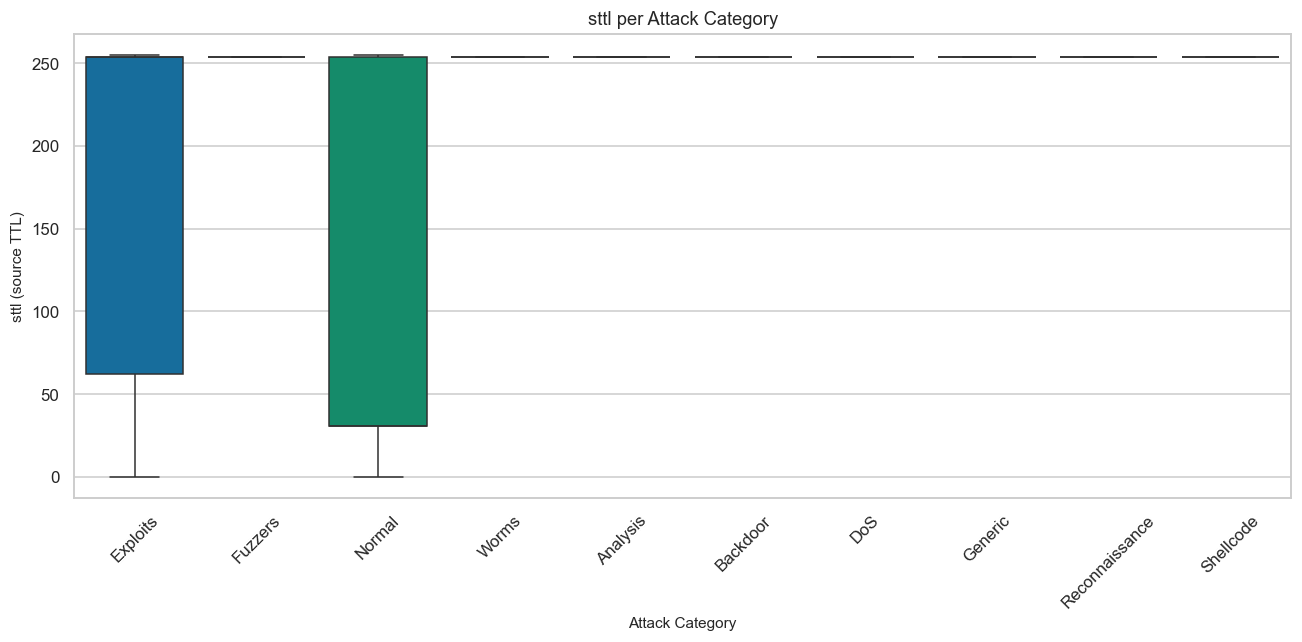

In [22]:
# Box plot: sttl per attack_cat
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='attack_cat', y='sttl', order=order, ax=ax,
            showfliers=False, palette='colorblind')
ax.set_title('sttl per Attack Category')
ax.set_xlabel('Attack Category')
ax.set_ylabel('sttl (source TTL)')
ax.tick_params(axis='x', rotation=45)

save(fig, '12_boxplot_sttl_per_attack')

**Observation:** `sttl` separates attack categories remarkably well — `Generic` clusters at TTL=254, `Normal` around 29, and others at different values. This is partly an artifact of the synthetic testbed (IXIA generator assigns TTLs by attack type). It is a strong feature but should be interpreted cautiously in a real deployment.

## 8. Preprocessing Decisions Summary

| Step | Decision | Rubric |
|------|----------|--------|
| Load | Concatenate both partition files; ignore swapped official split | A1 |
| Drop `id`, `ct_ftp_cmd` | Not unique / redundant with `is_ftp_login` | B1 |
| Missing values | None present (asserted at runtime) | B1 |
| Duplicates | **Drop 94,928 (36.8%)** — removes 42.6% test contamination | B1 |
| Outliers | **Clip** at train-set 1st/99th percentile, don't delete | B1 |
| Feature engineering | 6 domain features + 2 classification-only | B3 |
| Split | Stratified 80/20 on `attack_cat`, `random_state=42` | B2 |
| Rare levels | Fold to 'other', whitelist fit on train only | B2 |
| Encoding | `OneHotEncoder(handle_unknown='ignore', drop='first')` | B2 |
| Scaling | `StandardScaler` fit on train only | B2 |

## 9. Next Steps

- **Regression notebook** — train 10 models, comparison table, tuning, diagnostics
- **Classification notebook** — train 5 Part-A models, confusion matrices
- **Clustering notebook** — K-Means + Agglomerative (Review 2)